In [1]:
import numpy as np
import pandas as pd

# Machine Learning

from sklearn.base import TransformerMixin
from sklearn.datasets import make_circles
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVC

from typing import Callable, Dict, List, Optional, Self, Set, Tuple, Union
from numpy.typing import NDArray

import matplotlib.pyplot as plt

In [15]:
# Parameters

# Data Generation
numSamples = 250

# Preprocessing
polyDeg = 2

#Model
paramC = 1
kernelType = 'linear'
lC = [0.1, 0.25, 0.75, 1, 1.5, 2, 3]

# Visualiztion
numGridPts = 1001

In [16]:
from DataVisualization import PlotBinaryClassData, PlotDecisionBoundaryClosure
PlotDecisionBoundary = PlotDecisionBoundaryClosure(numGridPts, -1.5, 1.5, -1.5, 1.5)

In [12]:
mX, vY = make_circles(n_samples=numSamples, shuffle=True, noise=0.075, factor=0.5)
print(f'mX shape: {mX.shape}')
np.unique(vY, return_counts=True)

mX shape: (250, 2)


(array([0, 1]), array([125, 125]))

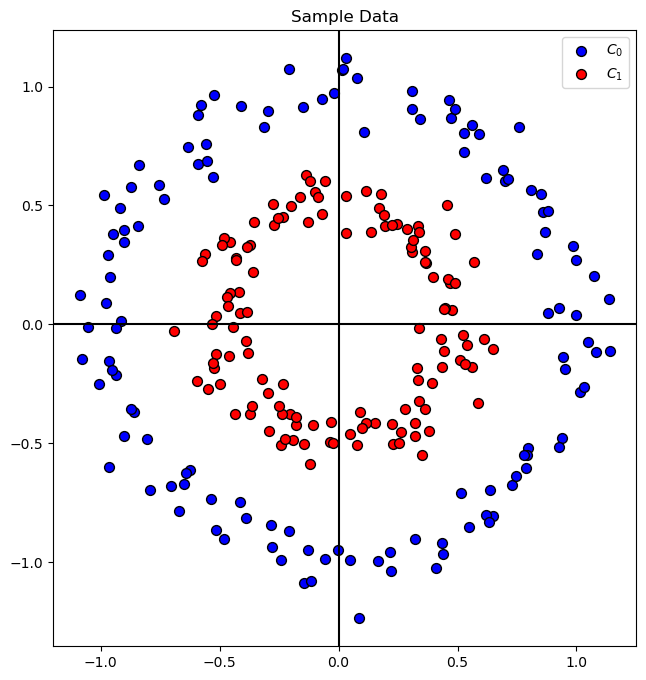

In [6]:
hA = PlotBinaryClassData(mX, vY, axisTitle='Sample Data')

In [13]:
lC

[0.1, 0.25, 0.75, 1, 1.5, 2, 3]

In [14]:
# Train linear SVM model

vAcc = np.zeros(shape = len(lC))
for ii, C in enumerate(lC):
    oLinSvc = SVC(C=C, kernel='linear').fit(mX, vY)
    vAcc[ii] = oLinSvc.score(mX, vY)

bestModelIdx = np.argmax(vAcc) # return index of max value in array
bestC = lC[bestModelIdx]

oLinSvc = SVC(C=bestC, kernel='linear').fit(mX, vY)

print(f'optimalc = {bestC}, provide score: {np.max(vAcc)} ')



optimalc = 1.5, provide score: 0.564 


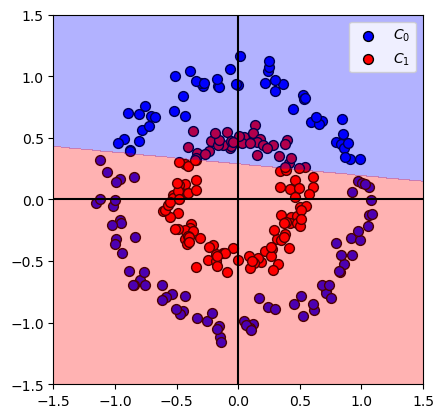

In [21]:
hF, hA = plt.subplots()
hA = PlotBinaryClassData(mX, vY, hA=hA)
hA = PlotDecisionBoundary(oLinSvc.predict,  hA = hA)

In [37]:
# Constaruct the PolynomialFeatures object

oPolyTrns = PolynomialFeatures(degree=polyDeg, include_bias=False)
oPolyTrns = oPolyTrns.fit(mX)
mX1 = oPolyTrns.transform(mX) 

In [38]:
vAcc = np.zeros(shape = len(lC))
for ii, C in enumerate(lC):
    oLinSvc = SVC(C=C, kernel='linear').fit(mX1, vY)
    vAcc[ii] = oLinSvc.score(mX1, vY)

bestModelIdx = np.argmax(vAcc) # return index of max value in array
bestC = lC[bestModelIdx]

oLinSvc = SVC(C=bestC, kernel='linear').fit(mX1, vY)

print(f'optimalc = {bestC}, provide score: {np.max(vAcc)} ')

optimalc = 0.1, provide score: 1.0 


In [45]:
oModelPipe = Pipeline([
    ('Transformer', oPolyTrns),
    ('Classifier', oLinSvc)
])

In [46]:
from sklearn.utils.validation import check_is_fitted
assert check_is_fitted(oModelPipe) is None, "The PipeLine is not fitted!"

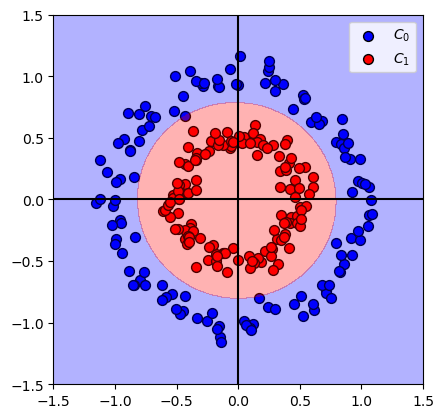

In [47]:
hF, hA = plt.subplots()
hA = PlotBinaryClassData(mX, vY, hA=hA)
hA = PlotDecisionBoundary(oModelPipe.predict,  hA = hA)